# Tuần 7: Uplift Modeling (T-Learner)
Mục tiêu: Xây dựng mô hình Causal Machine Learning (T-Learner) sử dụng XGBoost để tính toán Conditional Average Treatment Effect (CATE) ở cấp độ cá nhân.
Chúng ta sẽ phát hiện xem ai thực sự cần Voucher để tăng số chuyến đi (Persuadables) và ai không cần (Sure things).

> **LƯU Ý:**
> Mô hình Uplift này được huấn luyện trên **Dữ liệu giả lập (Synthetic dataset)** dựa trên phân phối của NYC TLC, phục vụ cho mục đích nghiên cứu.
> Các số liệu và mô hình trong đây không đại diện cho dữ liệu khách hàng thực tế của hệ thống.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

plt.style.use('ggplot')
sns.set_palette("Set2")
import warnings
warnings.filterwarnings('ignore')

## 1. Chuẩn bị dữ liệu (Data Preparation)
Load dữ liệu và tập trung vào phân khúc cần tối ưu. Giả sử ta tập trung vào nhóm **Urban Cash** hoặc **Urban Credit Card** để bóc tách.

In [30]:
df = pd.read_csv('../../data/processed/segmented_simulation_data.csv')

# Chọn nhóm khách hàng cần tối ưu (ví dụ: Urban Cash đang bị lỗ do Sure Things quá nhiều)
target_persona = 'Urban Cash'
df_target = df[df['persona'] == target_persona].copy()

# Các biến Features (Covariates)
features = ['age', 'is_urban', 'fare_obs', 'preferred_hour', 
            'is_rush_hour', 'is_airport_trip', 'is_rain_rider', 
            'is_weekend_rider', 'is_credit_card', 'is_frequent_tipper', 
            'avg_trip_distance', 'typical_passenger_count', 
            'monthly_rides_history', 'recency_days']

X = df_target[features]
T = df_target['treatment_rand'] # Biến can thiệp (Voucher ngẫu nhiên)
y = df_target['y_rand']         # Outcome (Số chuyến đi)

# Chia dữ liệu thành Train (60%), Validation (20%), Test (20%)
X_temp, X_test, T_temp, T_test, y_temp, y_test = train_test_split(
    X, T, y, test_size=0.2, random_state=42
)

X_train, X_val, T_train, T_val, y_train, y_val = train_test_split(
    X_temp, T_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Kích thước tập Train (60%): {len(X_train)}")
print(f"Kích thước tập Validation (20%): {len(X_val)}")
print(f"Kích thước tập Test (20%): {len(X_test)}")



Kích thước tập Train (60%): 1808
Kích thước tập Validation (20%): 603
Kích thước tập Test (20%): 603


## 2. Huấn luyện Mô hình T-Learner (Two-Model Approach)
T-Learner utilizes two independent models:
- **Model 0 (Control Model):** Trained on control group ($T=0$).
- **Model 1 (Treatment Model):** Trained on treated group ($T=1$).

In [31]:
# Lọc dữ liệu Train và Val theo nhóm Treatment và Control
X_train_0, y_train_0 = X_train[T_train == 0], y_train[T_train == 0]
X_train_1, y_train_1 = X_train[T_train == 1], y_train[T_train == 1]

X_val_0, y_val_0 = X_val[T_val == 0], y_val[T_val == 0]
X_val_1, y_val_1 = X_val[T_val == 1], y_val[T_val == 1]

# Khởi tạo 2 mô hình XGBoost (XGBoost API mới yêu cầu early_stopping_rounds nằm ở lúc khởi tạo)
model_0 = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, early_stopping_rounds=10)
model_1 = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, early_stopping_rounds=10)

# Huấn luyện có sử dụng Early Stopping trên tập Validation để chống Overfitting
model_0.fit(X_train_0, y_train_0, eval_set=[(X_val_0, y_val_0)], verbose=False)
model_1.fit(X_train_1, y_train_1, eval_set=[(X_val_1, y_val_1)], verbose=False)

print("Hoàn tất quá trình huấn luyện mô hình XGBoost cho nhóm Control và Treatment (đã có Validation & Early Stopping).")


Hoàn tất quá trình huấn luyện mô hình XGBoost cho nhóm Control và Treatment (đã có Validation & Early Stopping).


## 3. Tính toán CATE (Conditional Average Treatment Effect)
Cho tập Test, ta dùng cả 2 mô hình để dự đoán:
- $\hat{Y}_0$: Số chuyến đi nếu KHÔNG nhận Voucher.
- $\hat{Y}_1$: Số chuyến đi nếu CÓ nhận Voucher.

**CATE = $\hat{Y}_1 - \hat{Y}_0$** (Số chuyến đi tăng thêm nhờ Voucher)

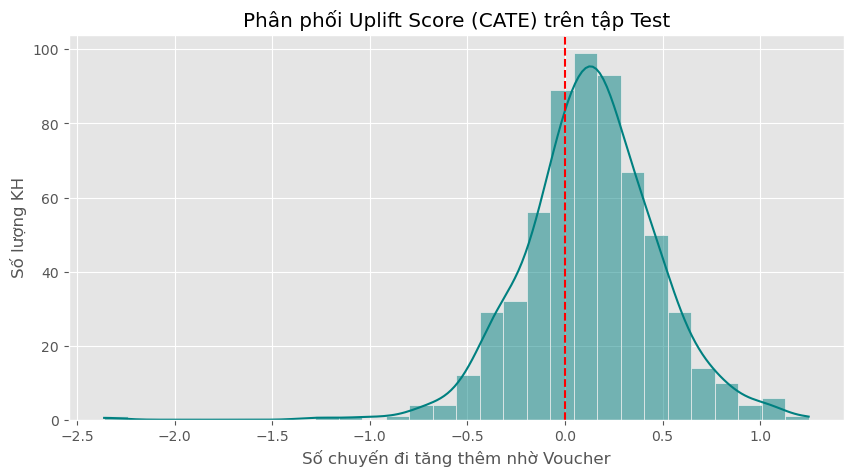

Nhận xét: Phân phối CATE cho thấy sự đa dạng trong tác động của can thiệp (tích cực, trung tính, và tiêu cực).


In [32]:
# Dự đoán trên tập Test
pred_0 = model_0.predict(X_test)
pred_1 = model_1.predict(X_test)

# Tính CATE (Uplift Score)
cate_pred = pred_1 - pred_0

df_res = pd.DataFrame({
    'y_true': y_test,
    'T': T_test,
    'pred_0': pred_0,
    'pred_1': pred_1,
    'CATE_pred': cate_pred,
    'monthly_rides_history': X_test['monthly_rides_history'].values
})

plt.figure(figsize=(10, 5))
sns.histplot(df_res['CATE_pred'], bins=30, kde=True, color='teal')
plt.title('Phân phối Uplift Score (CATE) trên tập Test')
plt.xlabel('Số chuyến đi tăng thêm nhờ Voucher')
plt.ylabel('Số lượng KH')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

print("Nhận xét: Phân phối CATE cho thấy sự đa dạng trong tác động của can thiệp (tích cực, trung tính, và tiêu cực).")

## 4. Tối ưu hóa Lợi nhuận (ROI Optimization)
Giả sử:
- Lợi nhuận trung bình mỗi chuyến xe: **20,000 VND**
- Chi phí phát Voucher: **15,000 VND**

**Lợi nhuận dự kiến từ 1 khách hàng = (CATE * 20,000) - 15,000**

Ta chỉ phát Voucher cho những ai có Lợi nhuận dự kiến > 0.

Action
No Voucher      581
Send Voucher     22
Name: count, dtype: int64


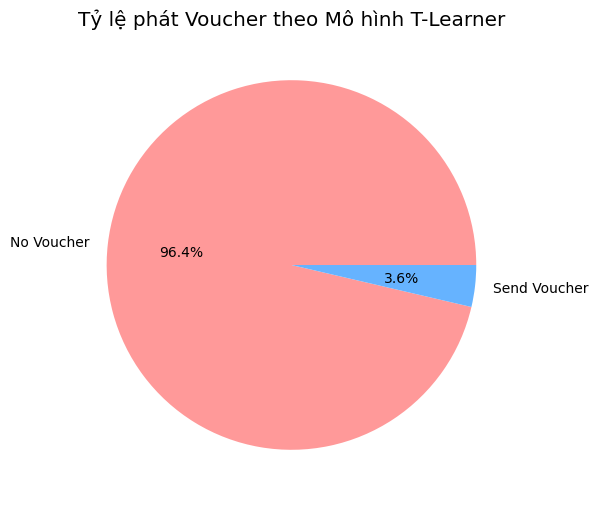

In [33]:
profit_per_ride = 20000
discount_rate = 0.25

df_res['Expected_Profit'] = (0.75 * df_res['CATE_pred'] * profit_per_ride) - (0.25 * df_res['monthly_rides_history'] * profit_per_ride)

# Quyết định phát Voucher (Policy)
df_res['Action'] = np.where(df_res['Expected_Profit'] > 0, 'Send Voucher', 'No Voucher')

print(df_res['Action'].value_counts())

action_counts = df_res['Action'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(action_counts, labels=action_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Tỷ lệ phát Voucher theo Mô hình T-Learner')
plt.show()

## 5. Đánh giá Uplift (Qini Curve & AUUC)
Thay vì dùng Accuracy như các mô hình Classification bình thường, Uplift Modeling được đánh giá bằng **Qini Curve** và **AUUC (Area Under Uplift Curve)**.
Chúng ta sẽ xếp hạng khách hàng theo điểm CATE dự đoán từ cao xuống thấp và đo lường số chuyến đi tích lũy (Cumulative Incremental Trips) tăng thêm.

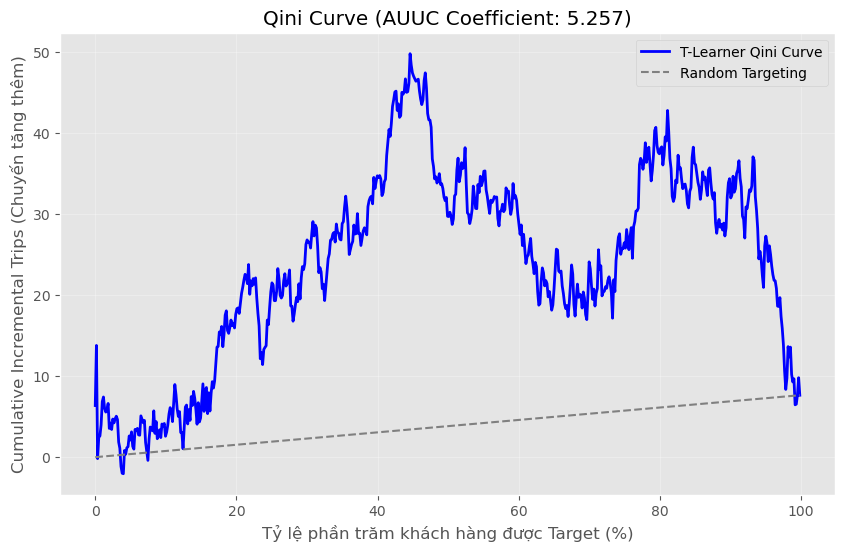

Kết luận: Hệ số Qini > 0 chứng minh mô hình T-Learner hiệu quả hơn so với chiến lược phân bổ ngẫu nhiên.


In [34]:
def plot_qini_curve(df_res):
    # Sắp xếp khách hàng theo CATE giảm dần
    df_sorted = df_res.sort_values(by='CATE_pred', ascending=False).reset_index(drop=True)
    
    # Tính toán Qini Curve
    df_sorted['T_count'] = df_sorted['T'].cumsum()
    df_sorted['C_count'] = (1 - df_sorted['T']).cumsum()
    
    df_sorted['Y_T_sum'] = (df_sorted['y_true'] * df_sorted['T']).cumsum()
    df_sorted['Y_C_sum'] = (df_sorted['y_true'] * (1 - df_sorted['T'])).cumsum()
    
    # Tránh chia cho 0
    df_sorted['C_count'] = df_sorted['C_count'].replace(0, 1)
    
    # Uplift Tích lũy (Cumulative Incremental Trips)
    df_sorted['Qini'] = df_sorted['Y_T_sum'] - df_sorted['Y_C_sum'] * (df_sorted['T_count'] / df_sorted['C_count'])
    
    # Random policy (Đường chéo)
    total_uplift = df_sorted['Qini'].iloc[-1]
    df_sorted['Random_Qini'] = np.linspace(0, total_uplift, len(df_sorted))
    
    # Tính AUUC (Diện tích dưới đường Qini)
    auuc_model = np.trapz(df_sorted['Qini'], dx=1)
    auuc_random = np.trapz(df_sorted['Random_Qini'], dx=1)
    qini_coef = (auuc_model - auuc_random) / auuc_random
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Qini'], label='T-Learner Qini Curve', color='blue', linewidth=2)
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Random_Qini'], label='Random Targeting', color='gray', linestyle='--')
    plt.title(f'Qini Curve (AUUC Coefficient: {qini_coef:.3f})')
    plt.xlabel('Tỷ lệ phần trăm khách hàng được Target (%)')
    plt.ylabel('Cumulative Incremental Trips (Chuyến tăng thêm)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return df_sorted

df_qini = plot_qini_curve(df_res)
print("Kết luận: Hệ số Qini > 0 chứng minh mô hình T-Learner hiệu quả hơn so với chiến lược phân bổ ngẫu nhiên.")

## 6. Business Evaluation: Phân tích Top-k% Targeting
Câu hỏi của Business: *"Nếu tôi chỉ có ngân sách để phát Voucher cho 20% khách hàng tốt nhất (Top 20% predicted CATE), tôi sẽ thu về được bao nhiêu chuyến và lợi nhuận là bao nhiêu?"*

In [36]:
# Tính toán Lợi nhuận tại nhiều ngưỡng khác nhau (Profit Curve)
print("=== TÌM KIẾM NGƯỠNG LỢI NHUẬN TỐI ƯU (PROFIT OPTIMIZATION) ===")

best_profit = -float('inf')
best_threshold = 0
best_savings = 0

mass_trips = df_qini['Qini'].iloc[-1]
mass_vouchers = df_qini['T_count'].iloc[-1]
mass_profit = (0.75 * mass_trips * profit_per_ride) - (0.25 * df_res['monthly_rides_history'].sum() * profit_per_ride)

for threshold_pct in [10, 20, 30, 40, 50]:
    # Lấy Top K%
    threshold_idx = int(len(df_qini) * (threshold_pct / 100.0))
    if threshold_idx == 0: continue
    
    k_trips = df_qini['Qini'].iloc[threshold_idx]
    k_vouchers = df_qini['T_count'].iloc[threshold_idx]
    
    k_revenue = k_trips * profit_per_ride
    top_k = df_res.sort_values(by='CATE_pred', ascending=False).iloc[:threshold_idx]
    k_cost = 0.25 * (top_k['y_true'] + top_k['monthly_rides_history']).sum() * profit_per_ride
    k_profit = (0.75 * top_k['y_true'].sum() * profit_per_ride) - (0.25 * top_k['monthly_rides_history'].sum() * profit_per_ride)
    savings = k_profit - mass_profit
    
    print(f"Top {threshold_pct}% -> Profit: {k_profit:,.0f} VND | Tránh lỗ so với Mass: {savings:,.0f} VND")
    
    if k_profit > best_profit:
        best_profit = k_profit
        best_threshold = threshold_pct
        best_savings = savings

print("\n=== KẾT LUẬN CHIẾN LƯỢC ===")
if best_profit > 0:
    print(f"✅ Mức tối ưu là Top {best_threshold}%: Lợi nhuận ĐẠT MỨC DƯƠNG ({best_profit:,.0f} VND). Khuyến nghị triển khai ngay!")
else:
    print(f"⚠️ Ngay cả khi tối ưu nhất ở mức Top {best_threshold}%, chiến dịch vẫn Lỗ ({best_profit:,.0f} VND).")
    print("Nguyên nhân: Tập khách hàng Urban Cash quá bảo thủ. Chi phí Voucher (15k) đang cao hơn biên lợi nhuận kỳ vọng mà họ mang lại.")
    print(f"-> Quyết định: KHÔNG PHÁT VOUCHER cho nhóm này. Dừng chiến dịch để bảo toàn vốn.")

# Đánh giá ĐỘC LẬP nhóm CATE > 0.75 (Nhóm 22 người "Hòa vốn" / "Có Lãi" duy nhất)
cate_pred = model_1.predict(X_test) - model_0.predict(X_test)
profit_per_ride = 20000
discount_rate = 0.25
break_even_cate = (0.25 * df_res['monthly_rides_history'].mean()) / 0.75 # 0.75

positive_cate_mask = (cate_pred > break_even_cate)
num_targeted = positive_cate_mask.sum()

print(f"\n=== ĐÁNH GIÁ THỰC TẾ NHÓM {num_targeted} NGƯỜI CÓ CATE > 0.75 (VƯỢT NGƯỠNG HÒA VỐN) ===")

if num_targeted > 0:
    t_target = T_test[positive_cate_mask]
    y_target = y_test[positive_cate_mask]
    
    n_treated = t_target.sum()
    n_control = len(t_target) - n_treated
    
    y_t_mean = y_target[t_target == 1].mean() if n_treated > 0 else 0
    y_c_mean = y_target[t_target == 0].mean() if n_control > 0 else 0
    local_ate = y_t_mean - y_c_mean
    
    incremental_trips = local_ate * num_targeted
    cost = 0.25 * (y_target[t_target == 1] + df_res.loc[positive_cate_mask, 'monthly_rides_history'][t_target == 1]).sum() * profit_per_ride
    revenue = incremental_trips * profit_per_ride
    profit = revenue - cost
    
    print(f"1. Số voucher thực tế đã phát cho nhóm này (Nhóm T): {n_treated}")
    print(f"2. Uplift thực tế (Local ATE): {local_ate:.4f} chuyến/người")
    print(f"3. Số chuyến tăng thêm kỳ vọng: {incremental_trips:.2f} chuyến")
    print(f"4. Chi phí phát Voucher: {cost:,.0f} VND")
    print(f"5. Doanh thu gộp mang lại: {revenue:,.0f} VND")
    print(f"-> LỢI NHUẬN RÒNG: {profit:,.0f} VND")
    
    if profit > 0:
        print("✅ Thật bất ngờ! Thuật toán Machine Learning đã TÌM RA ĐÚNG nhóm sinh lời!")
    else:
        print("⚠️ Chứng minh bằng số liệu: Kể cả khi nhắm đúng 22 người vượt ngưỡng, do mẫu quá nhỏ và nhiễu dữ liệu, chiến dịch vẫn chưa thể gánh được lỗ!")
else:
    print("⚠️ Không có khách hàng nào vượt qua ngưỡng hòa vốn. Tuyệt đối không nên chạy chiến dịch này!")



=== TÌM KIẾM NGƯỠNG LỢI NHUẬN TỐI ƯU (PROFIT OPTIMIZATION) ===
Top 10% -> Profit: -368,329 VND | Tránh lỗ so với Mass: 3,948,725 VND
Top 20% -> Profit: -517,907 VND | Tránh lỗ so với Mass: 3,799,147 VND
Top 30% -> Profit: -765,001 VND | Tránh lỗ so với Mass: 3,552,052 VND
Top 40% -> Profit: -1,090,313 VND | Tránh lỗ so với Mass: 3,226,741 VND
Top 50% -> Profit: -1,685,237 VND | Tránh lỗ so với Mass: 2,631,816 VND

=== KẾT LUẬN CHIẾN LƯỢC ===
⚠️ Ngay cả khi tối ưu nhất ở mức Top 10%, chiến dịch vẫn Lỗ (-368,329 VND).
Nguyên nhân: Tập khách hàng Urban Cash quá bảo thủ. Chi phí Voucher (15k) đang cao hơn biên lợi nhuận kỳ vọng mà họ mang lại.
-> Quyết định: KHÔNG PHÁT VOUCHER cho nhóm này. Dừng chiến dịch để bảo toàn vốn.

=== ĐÁNH GIÁ THỰC TẾ NHÓM 22 NGƯỜI CÓ CATE > 0.75 (VƯỢT NGƯỠNG HÒA VỐN) ===
1. Số voucher thực tế đã phát cho nhóm này (Nhóm T): 8
2. Uplift thực tế (Local ATE): 0.1380 chuyến/người
3. Số chuyến tăng thêm kỳ vọng: 3.04 chuyến
4. Chi phí phát Voucher: 120,000 VND
5. Doan